In [47]:
import fcs_utils.process_id as process_id
import fcs_utils.primary_gates as primary_gates
from pathlib import Path
import flowkit as fk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### 1. Set up necessary functions

In [48]:
clicks = []  # list of (x, y)

def on_click(event):
    # ignore clicks outside axes
    if event.inaxes is None:
        return
    # sometimes xdata/ydata can be None if click can't be mapped
    if event.xdata is None or event.ydata is None:
        print("No data coords for this click (xdata/ydata is None).")
        return
    # right click: undo
    if event.button == 3:
        if clicks:
            removed = clicks.pop()
            print("Undo:", removed, "| n =", len(clicks))
        return
    # left click: add
    if event.button == 1:
        pt = (float(event.xdata), float(event.ydata))
        clicks.append(pt)
        print("Add:", pt, "| n =", len(clicks))

### 2. Set up input information

In [49]:
# INPUT_DIR = Path("../examples/260105_MOLM13_ZE5/data/260105_MOLM13_ZE5_day7_rep1")
# CELLTYPE = "MOLM13"
# CYTOMETER = "ZE5"
# MAXVAL = 2**24-1

# INPUT_DIR = Path("../examples/260101_EL4_CytoFlex/data/260101_EL4_CytoFlex_day3_rep1")
# CELLTYPE = "EL4"
# CYTOMETER = "CytoFlex"
# MAXVAL = 2**18-1

INPUT_DIR = Path("../examples/260105_HEK293T_GFPDisruption/data/260106_HEK293T_GFPDisruption_day3_rep2")
CELLTYPE = "HEK293T"
CYTOMETER = "CytoFlex"
MAXVAL = 2**18-1

In [36]:
SAMPLE_INDEX = 0
TRANFORMED = True
df_color = pd.read_csv("../color_info.csv")
dict_color = df_color.set_index("Fluorophore")[CYTOMETER].to_dict()
process_id.setup_fcsprocess(INPUT_DIR, dict_color)
session = primary_gates.init_session(INPUT_DIR, Path(), MAXVAL)
# FSC-A vs SSC-A
x_label = None
y_label = None
time_channel = None
sample_id = session.get_sample_ids()[SAMPLE_INDEX]
print(f"Processing: {sample_id}")
sample = session.get_sample(sample_id)
for ch in sample.pnn_labels:
    if "FSC" in ch and "-A" in ch:
        x_label = ch
    elif "SSC" in ch and "-A" in ch:
        y_label = ch
    elif "time" in ch.lower():
        time_channel = ch
if TRANFORMED:
    x_events = sample.get_channel_events(x_label, source="xform")
    y_events = sample.get_channel_events(y_label, source="xform")
else:
    x_events = sample.get_channel_events(x_label, source="raw")
    y_events = sample.get_channel_events(y_label, source="raw")

Processing: HEK293T_Mock_0ng.fcs


In [37]:
session.gating_strategy.transformations

{'FSC-H': LogTransform(t: 262143, m: 4.5),
 'FSC-A': LogTransform(t: 262143, m: 4.5),
 'SSC-H': LogTransform(t: 262143, m: 4.5),
 'SSC-A': LogTransform(t: 262143, m: 4.5),
 'GFP-H': LogicleTransform(t: 262143, w: 0.5, m: 4.5, a: 0),
 'GFP-A': LogicleTransform(t: 262143, w: 0.5, m: 4.5, a: 0),
 'mCherry-H': LogicleTransform(t: 262143, w: 0.5, m: 4.5, a: 0),
 'mCherry-A': LogicleTransform(t: 262143, w: 0.5, m: 4.5, a: 0),
 'FSC-Width': LogTransform(t: 262143, m: 4.5),
 'Time': LinearTransform(t: 1, a: 0)}

### 3. Draw a polygonal gate  
- Draw a polygonal gate by clicking multiple times on the shown figure after running the following cell. 
- Proceed to the next cell to check the drawn gate.

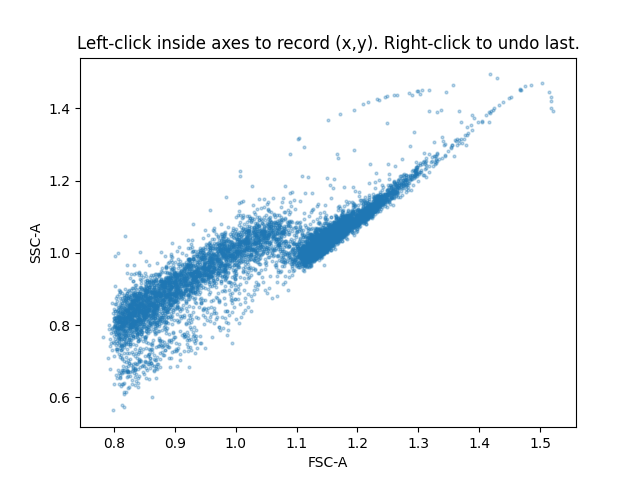

In [40]:
%matplotlib widget
clicks = []
plt.close("all")
fig, ax = plt.subplots()
ax.set_title("Left-click inside axes to record (x,y). Right-click to undo last.")
ax.plot(x_events, y_events, 'o', markersize=2, alpha=0.3)
ax.set_xlabel("FSC-A")
ax.set_ylabel("SSC-A")
cid = fig.canvas.mpl_connect("button_press_event", on_click)


### 4. Check the drawn polygonal gate  
- Check the drawn gate by running the following cell.
- If the gate looks good, proceed to saving the gate as .gml file.
- Or, go back to the step 3 to re-draw another gate.

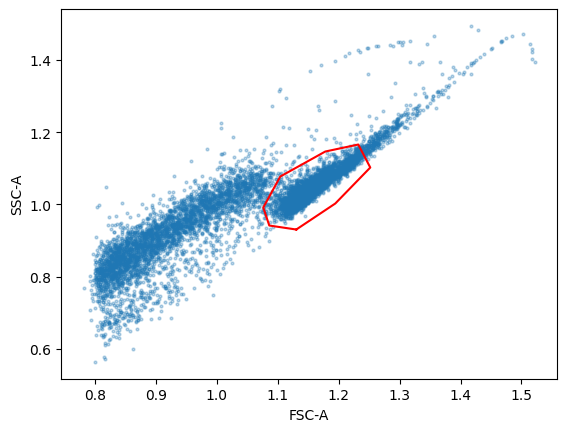

In [41]:
fig.canvas.mpl_disconnect(cid)
plt.close(fig)
%matplotlib inline
fig, ax = plt.subplots()
ax.plot(x_events, y_events, 'o', markersize=2, alpha=0.3)  # replace with your scatter
ax.set_xlabel("FSC-A")
ax.set_ylabel("SSC-A")
saved_coords = np.array(clicks).copy()
ax.plot(
    np.concatenate([saved_coords[:,0], saved_coords[0:1,0]]), 
    np.concatenate([saved_coords[:,1], saved_coords[0:1,1]]),
    "r",
)


### 5. Save the gate

In [42]:
# Adding an empty TimeQC gate on Time vs SSC-A
gs = fk.GatingStrategy()
dim_a = fk.Dimension(time_channel, range_min=0, range_max=100000,)
polygate = fk.gates.RectangleGate(
    "TimeQC",
    dimensions=[dim_a,],
)
gs.add_gate(polygate, gate_path=("root",))

if TRANFORMED:
    x_data = np.asarray(saved_coords[:,0]).reshape(-1,1)
    y_data = np.asarray(saved_coords[:,1]).reshape(-1,1)
    x_transform = session.get_transforms()[x_label]
    y_transform = session.get_transforms()[y_label]
    dim_a = fk.Dimension(x_label, transformation_ref=x_label)
    dim_b = fk.Dimension(y_label, transformation_ref=y_label)
    gs.add_transform(x_label, x_transform)
    gs.add_transform(y_label, y_transform)
else:
    x_data = np.asarray(saved_coords[:,0]).reshape(-1,1)
    y_data = np.asarray(saved_coords[:,1]).reshape(-1,1)
    dim_a = fk.Dimension(x_label)
    dim_b = fk.Dimension(y_label)

vertices = np.concatenate([x_data, y_data], axis=1)

polygate = fk.gates.PolygonGate(
    "Viable",
    dimensions=[dim_a, dim_b],
    vertices=vertices,
)
gs.add_gate(polygate, gate_path=("root", "TimeQC",))


with open(f"../gating_strategies/default_gates_{CYTOMETER}_{CELLTYPE}.gml", "wb") as fh:
    fk.export_gatingml(gs, fh)

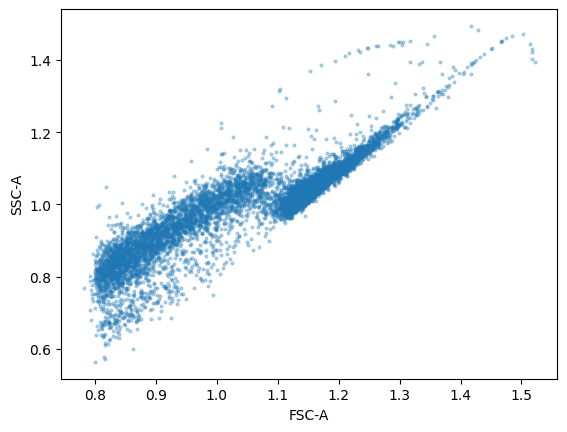

In [59]:
SAMPLE_INDEX = 0
TRANFORMED = True
df_color = pd.read_csv("../color_info.csv")
dict_color = df_color.set_index("Fluorophore")[CYTOMETER].to_dict()
process_id.setup_fcsprocess(INPUT_DIR, dict_color)
session = primary_gates.init_session(INPUT_DIR, Path(f"../examples/260106_HEK293T_mCherry/output/260106_HEK293T_mCherry_day3_rep1/gating_strategy_standard.gml"), MAXVAL)

fig, ax = plt.subplots()
ax.plot(x_events, y_events, 'o', markersize=2, alpha=0.3)  # replace with your scatter
ax.set_xlabel("FSC-A")
ax.set_ylabel("SSC-A")
saved_coords = np.array(clicks).copy()
